In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../resources/stack_overflowcsv.csv')
df.head()
print(df.info())

df['ConvertedSalary'] = df['ConvertedSalary'].fillna(df['ConvertedSalary'].mean())
df['ConvertedSalary'] = df['ConvertedSalary'].astype('float64')

print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SurveyDate                  999 non-null    str    
 1   FormalEducation             999 non-null    str    
 2   ConvertedSalary             665 non-null    float64
 3   Hobby                       999 non-null    str    
 4   Country                     999 non-null    str    
 5   StackOverflowJobsRecommend  487 non-null    float64
 6   VersionControl              999 non-null    str    
 7   Age                         999 non-null    int64  
 8   Years Experience            999 non-null    int64  
 9   Gender                      693 non-null    str    
 10  RawSalary                   665 non-null    str    
dtypes: float64(2), int64(2), str(7)
memory usage: 173.4 KB
None
SurveyDate                        str
FormalEducation                   str
ConvertedSalary         

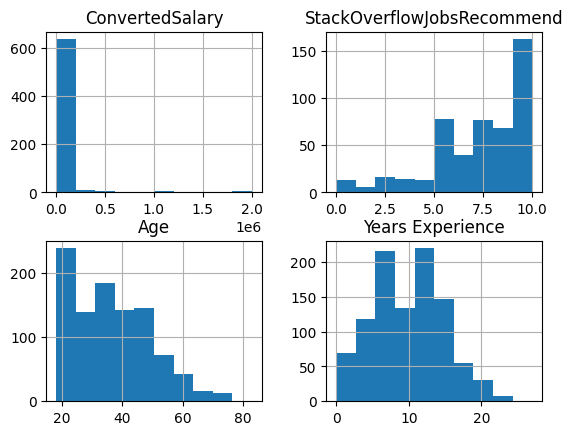

In [5]:
df.hist()
plt.show()

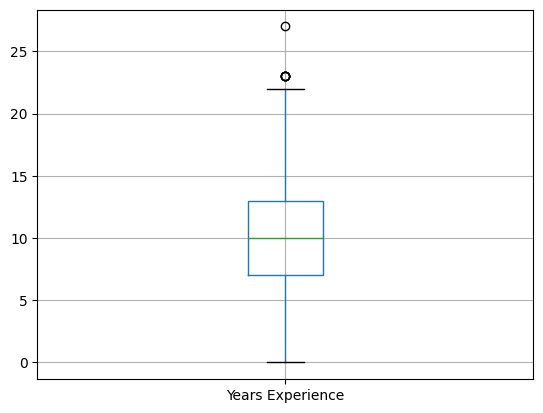

In [6]:
df[['Years Experience']].boxplot()
plt.show()

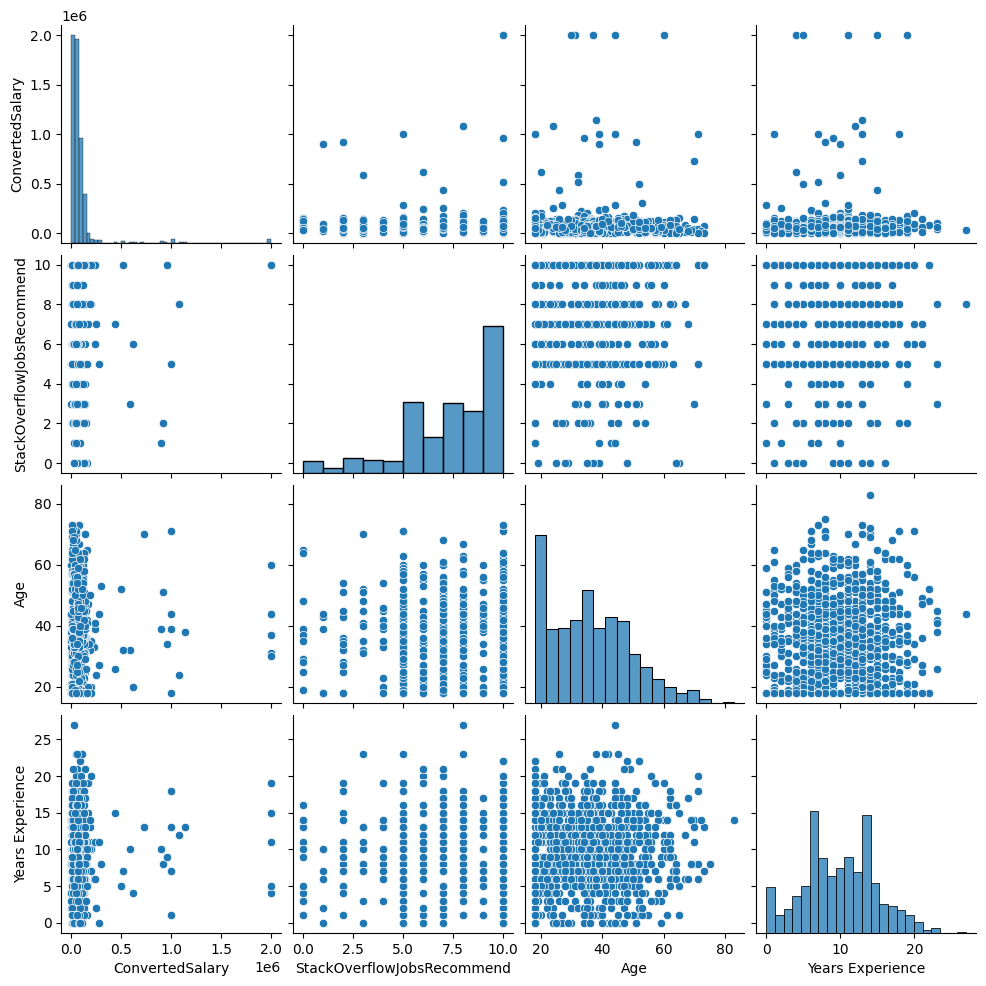

In [9]:
sns.pairplot(df)

In [11]:
df.describe()

,ConvertedSalary,StackOverflowJobsRecommend,Age,Years Experience
count,6.650000e+02,487.000000,999.000000,999.000000
mean,9.256517e+04,7.061602,36.003003,9.961962
std,2.091344e+05,2.621591,13.255127,4.878129
min,0.000000e+00,0.000000,18.000000,0.000000
25%,2.755000e+04,5.000000,25.000000,7.000000
50%,5.556200e+04,7.000000,35.000000,10.000000
75%,8.823800e+04,10.000000,45.000000,13.000000
max,2.000000e+06,10.000000,83.000000,27.000000


# Scalling and transformation

In [27]:
df.head()

,SurveyDate,FormalEducation,ConvertedSalary,Hobby,Country,StackOverflowJobsRecommend,VersionControl,Age,Years Experience,Gender,RawSalary
0,2/28/18 20:20,Bachelor's degree (BA. BS. B.Eng.. etc.),NaN,Yes,South Africa,NaN,Git,21,13,Male,NaN
1,6/28/18 13:26,Bachelor's degree (BA. BS. B.Eng.. etc.),70841.0,Yes,Sweeden,7.0,Git;Subversion,38,9,Male,"70,841.00"
2,6/6/18 3:37,Bachelor's degree (BA. BS. B.Eng.. etc.),NaN,No,Sweeden,8.0,Git,45,11,NaN,NaN
3,5/9/18 1:06,Some college/university study without earning ...,21426.0,Yes,Sweeden,NaN,Zip file back-ups,46,12,Male,"21,426.00"
4,4/12/18 22:41,Bachelor's degree (BA. BS. B.Eng.. etc.),41671.0,Yes,UK,8.0,Git,39,7,Male,"£41,671.00"


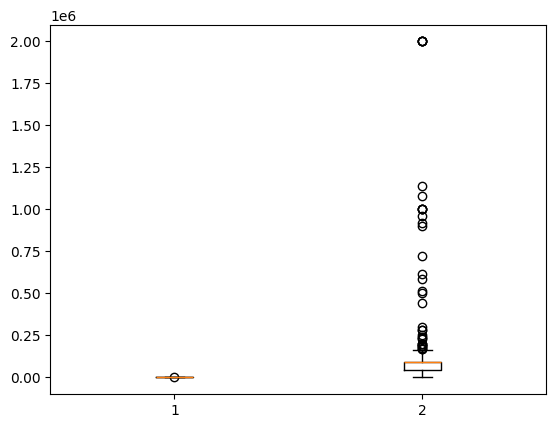

In [3]:
plt.boxplot(df[['Age','ConvertedSalary']])
plt.show()

<Axes: >

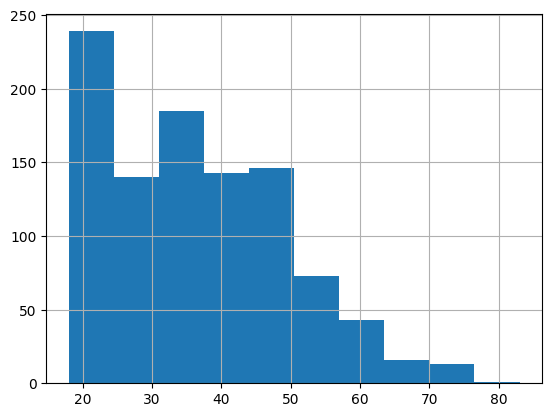

In [4]:
df['Age'].hist()

# Min-Max Scalling

<Axes: >

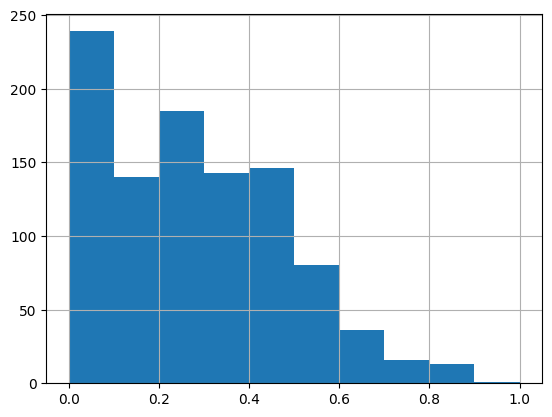

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(df[['Age']])

df['normalized_age'] = scaler.transform(df[['Age']])


df['normalized_age'].hist()

# Standardization

<Axes: >

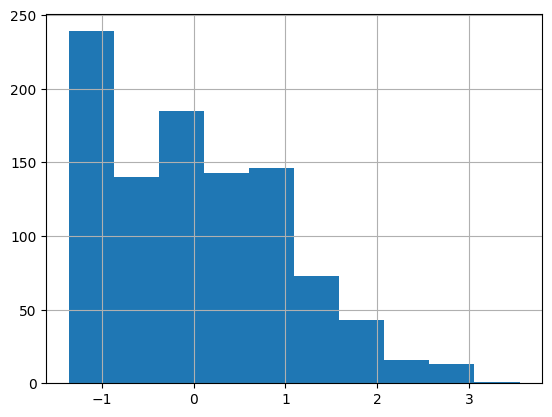

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df[['Age']])

df['standardized_col'] = scaler.transform(df[['Age']])

df['standardized_col'].hist()

# Log Transformation

<Axes: >

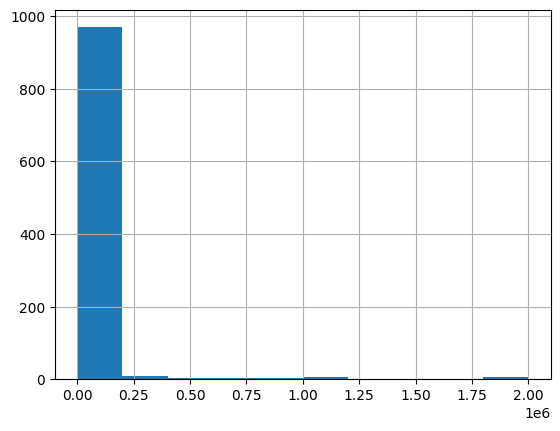

In [10]:
df['ConvertedSalary'].hist()

<Axes: >

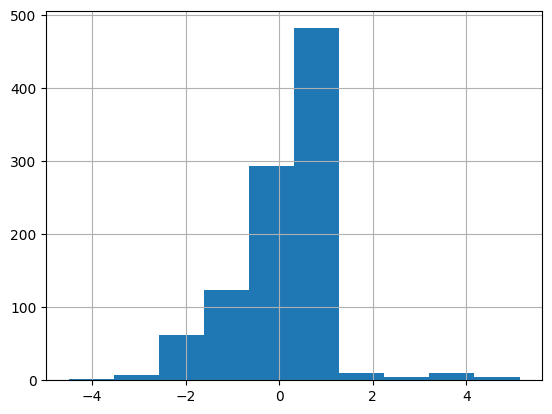

In [12]:
from sklearn.preprocessing import PowerTransformer
log = PowerTransformer()

log.fit(df[['ConvertedSalary']])

df['log_ConvertedSalary'] = log.transform(df[["ConvertedSalary"]])

df['log_ConvertedSalary'].hist()

# Removing Outliers

<Axes: >

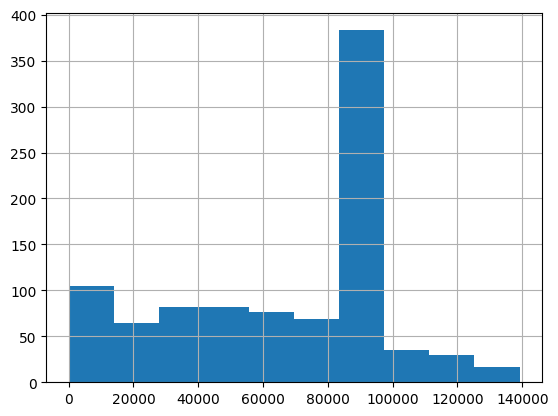

In [15]:
q_cuttoff = df['ConvertedSalary'].quantile(0.95)
mask = df['ConvertedSalary'] < q_cuttoff
trimmed_df = df[mask]

trimmed_df['ConvertedSalary'].hist()

# Standard Deviation Based Detection

<Axes: >

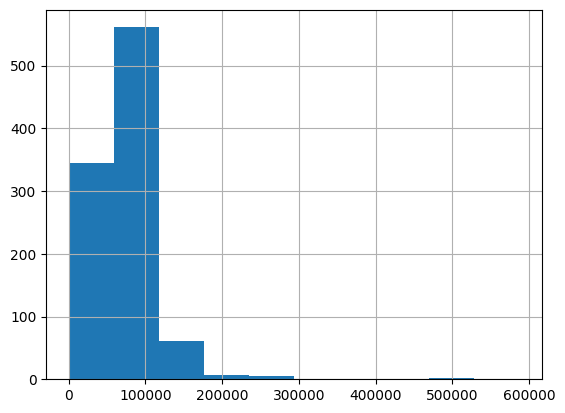

In [18]:
mean = df['ConvertedSalary'].mean()
std = df['ConvertedSalary'].std()

cut_off = std * 3

lower , upper = mean - cut_off , mean + cut_off

new_df = df[(df['ConvertedSalary'] < upper) & (df['ConvertedSalary'] > lower)]

new_df['ConvertedSalary'].hist()

# Scalling and transforming new data